# Lab 4 by Caleb Christian

## Part 1

In [14]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [4]:
peng = pd.read_csv("C:\\Users\\chair\\DS6021_F26\\data\\penguins.csv").dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm", "sex"]
).reset_index(drop=True)

peng.shape

(333, 8)

Question 1

In [6]:
import statsmodels.formula.api as smf

firstmodel = smf.ols(
    "body_mass_g ~ flipper_length_mm + C(sex) + C(species)",
    data=peng
).fit()

firstmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     534.0
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          3.37e-142
Time:                        16:19:15   Log-Likelihood:                -2364.4
No. Observations:                 333   AIC:                             4739.
Df Residuals:                     328   BIC:                             4758.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                -365.8174    532.050     -0.688      0.492   -1412.479     680.844
C(sex)[T.male]            530.3811     37.810     14.027      0.000     456.000     604.762
C(species)[T.Chinstrap]   -87.6345     46.347     -1.891      0.060    -178.810       3.541
C(species)[T.Gentoo]      836.2600     85.185      9.817      0.000     668.681    1003.839
flipper_length_mm          20.0249      2.846      7.037      0.000      14.427      25.623
==============================================================================
Omnibus:                        1.575   Durbin-Watson:                   2.097
Prob(Omnibus):                  0.455   Jarque-Bera (JB):                1.556
Skew:                           0.094   Prob(JB):                        0.459
Kurtosis:                       2.723   Cond. No.                     6.69e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.69e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Analyzing this OLS model, we can see that the R^2 is strong with 0.867.

The reference for sex is female and for species is the adelie species.

So for the coefficient for the C(species)[T.gentoo] means that it is predicted for the gentoo species to be 836.26 heavier than an adelie species.

Question 2

In [7]:
X = peng[["flipper_length_mm", "sex", "species"]]
y = peng["body_mass_g"]

X = pd.get_dummies(X, drop_first=True)

In [15]:
secondmodel = LinearRegression()
secondmodel.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 20.02,530.38,-87.63,836.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['flipper_length_mm','sex_male','species_Chinstrap','species_Gentoo']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-365.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [16]:
secondmodel.intercept_

np.float64(-365.81744976158643)

In [17]:
secondmodel.coef_

array([ 20.02491543, 530.38109449, -87.63447792, 836.26000815])

In [18]:
secondmodel.score(X,y)

0.8668883562330879

I think the way to get confidence intervals is to take our original data, and perform bootstrapping to our samples and after we fit the linear regression using sklearn we keep repeating the process till we get the actual coefficient percents to get the 95% CI

Question 3

In [26]:
ohx = peng[["flipper_length_mm", "sex", "species"]]
ohx = pd.get_dummies(ohx)
ohx.head()

,flipper_length_mm,sex_female,sex_male,species_Adelie,species_Chinstrap,species_Gentoo
0,181.0,False,True,True,False,False
1,186.0,True,False,True,False,False
2,195.0,True,False,True,False,False
3,193.0,True,False,True,False,False
4,190.0,False,True,True,False,False


Species has 3 columns and sex has 2

In [27]:
ohxmodel = LinearRegression()
ohxmodel.fit(ohx, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 20.02,-265.19, 265.19,-249.54,-337.18, 586.72]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['flipper_length_mm','sex_female','sex_male','species_Adelie', 'species_Chinstrap','species_Gentoo']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,148.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [28]:
ohxmodel.score(ohx, y)

0.8668883562330879

It seems as the R^2 is the same as the predicted values from question 2

In [29]:
ohxmodel.coef_

array([  20.02491543, -265.19054724,  265.19054724, -249.54184341,
       -337.17632133,  586.71816474])

In [33]:
#used llm to figure out how to get titles for coeff names
coef = pd.Series(ohxmodel.coef_, index=ohx.columns)
coef

flipper_length_mm     20.024915
sex_female          -265.190547
sex_male             265.190547
species_Adelie      -249.541843
species_Chinstrap   -337.176321
species_Gentoo       586.718165
dtype: float64

In [34]:
coef["species_Chinstrap"] - coef["species_Adelie"]

np.float64(-87.63447791888186)

In [35]:
coef["species_Gentoo"] - coef["species_Adelie"]

np.float64(836.2600081474632)

In [36]:
coef["sex_male"] - coef["sex_female"]

np.float64(530.3810944866989)

So looking at the coefficients from the dummy variable model we made vs the ones we just made with one hot, we can see that the differences are exactly the same as the coefficients from question 2.

It seems here that dropping a category does not really change anything it just makes the coefficients better to interpret. The more categories we keep, the more likely we might get some overalpping info. So for one hot encoding it isnt the best to keep every category caus ewe might get redundant info.

Question 4

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preproc = ColumnTransformer([
    ("num", "passthrough", ["flipper_length_mm"]),
    ("cat", OneHotEncoder(drop="first"), ["sex", "species"])
])

pipe = Pipeline([
    ("preproc", preproc),
    ("model", LinearRegression())
])

X_pipe = peng[["flipper_length_mm", "sex", "species"]]

pipe.fit(X_pipe, y)

features = pipe["preproc"].get_feature_names_out()
coefficients = pipe["model"].coef_

pd.Series(coefficients, index=features)

num__flipper_length_mm     20.024915
cat__sex_male             530.381094
cat__species_Chinstrap    -87.634478
cat__species_Gentoo       836.260008
dtype: float64

In [41]:
predictedmodel = pd.DataFrame({
    "flipper_length_mm": [215],
    "sex": ["male"],
    "species": ["Gentoo"]
})

In [42]:
pipe.predict(predictedmodel)

array([5306.18047038])

Using my calculator and plugging in the coefficients, we get the same answer of about 5306.18

## Part 2

Question 1

In [43]:
X2 = peng[["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]]
y2 = peng["body_mass_g"]

thirdmodel = LinearRegression()
thirdmodel.fit(X2, y2)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[50.76, 3.29,17.84]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['flipper_length_mm','bill_length_mm','bill_depth_mm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6445
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [44]:
thirdmodel.intercept_

np.float64(-6445.476043030191)

In [45]:
thirdmodel.score(X2, y2)

0.7639366781169292

In [46]:
pd.Series(thirdmodel.coef_, index = X2.columns)

flipper_length_mm    50.762132
bill_length_mm        3.292863
bill_depth_mm        17.836391
dtype: float64

I think we should drop the bill_length_mm because it is the smallest coefficient.

In [49]:
X2["bill_length_mm"] = X2["bill_length_mm"] / 10
thirdmodelcm = LinearRegression()
thirdmodelcm.fit(X2, y2)

thirdmodelcm.intercept_
thirdmodelcm.score(X2, y2)


0.7639366781169292

In [50]:
pd.Series(thirdmodelcm.coef_, index = X2.columns)

flipper_length_mm      50.762132
bill_length_mm       3292.862539
bill_depth_mm          17.836391
dtype: float64

I think bill_depth_mm would be the next deleted thing according to RFE

Question 2

In [52]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X2 = peng[["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]]

standardmodel = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

standardmodel.fit(X2, y2)

pd.Series(
    standardmodel[1].coef_,
    index=X2.columns
)

flipper_length_mm    710.401046
bill_length_mm        17.980514
bill_depth_mm         35.071275
dtype: float64

I believe the coefficient of flipper length tells us that by every 1 standard deviation increase in flipper length, the change in body mass is 710.401

In [53]:
#got this from an llm as well
pd.Series(
    abs(standardmodel[1].coef_),
    index=X2.columns
).sort_values(ascending=False)

flipper_length_mm    710.401046
bill_depth_mm         35.071275
bill_length_mm        17.980514
dtype: float64

RFE would drop bill_length_mm 

In [56]:
X2["bill_length_mm"] = X2["bill_length_mm"] / 10

standardmodel_cm = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

standardmodel_cm.fit(X2, y2)

pd.Series(
    standardmodel_cm[1].coef_,
    index=X2.columns
)

flipper_length_mm    710.401046
bill_length_mm        17.980514
bill_depth_mm         35.071275
dtype: float64

It seems that the unit conversion did not matter this time. I think it is due to the StandardScalar function.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
MinMax = make_pipeline(
    MinMaxScaler(),
    LinearRegression()
)
MinMax.fit(X2, y2)

pd.Series(MinMax[1].coef_, index=X2.columns)

flipper_length_mm    2994.965769
bill_length_mm         90.553720
bill_depth_mm         149.825685
dtype: float64

In [ ]:
from sklearn.preprocessing import RobustScaler
Robust = make_pipeline(
    RobustScaler(),
    LinearRegression()
)
Robust.fit(X2, y2)

pd.Series(Robust[1].coef_, index=X2.columns)

flipper_length_mm    1167.529028
bill_length_mm         29.965049
bill_depth_mm          55.292812
dtype: float64

Not all the scalars agree on the ranking. Standard scaling is using 1 standard deviation as a unit, min max scalar is using a range of 0-1 as a unit, robust scalar uses a median as a unit.

In [63]:
center = make_pipeline(
    StandardScaler(with_std=False),
    LinearRegression()
)
center.fit(X2, y2)
pd.Series(center[1].coef_, index=X2.columns)

flipper_length_mm     50.762132
bill_length_mm       329.286254
bill_depth_mm         17.836391
dtype: float64

Question 4

In [64]:
bike = pd.read_csv("C:\\Users\\chair\\DS6021_F26\\data\\bike-sharing-daily.csv", parse_dates=["dteday"])

<Axes: xlabel='casual', ylabel='Count'>

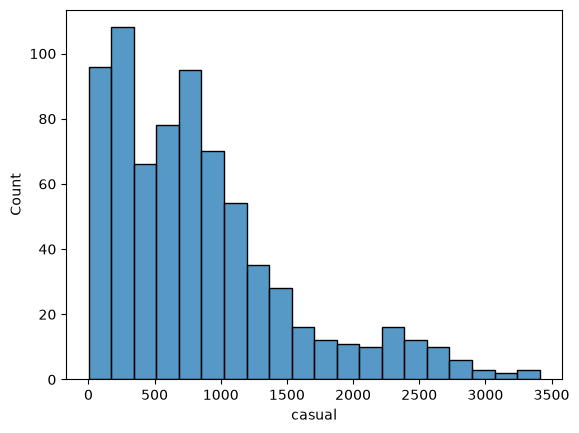

In [66]:
sns.histplot(data=bike, x="casual")

So this graph looks like a right skewed distribution if you look at the tail on the right side. It seems the more casual riders, the fewer days with a lot of riders.

<Axes: ylabel='casual'>

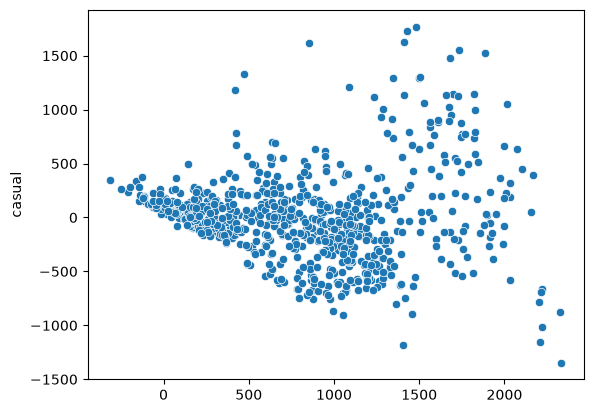

In [68]:
x_b = bike[["temp", "hum", "windspeed", "workingday"]]
y_b = bike["casual"]

bikemodel = LinearRegression()
bikemodel.fit(x_b, y_b)

pred = bikemodel.predict(x_b)
residuals = y_b - pred

sns.scatterplot(x=pred, y=residuals)

It seems that the residuals are more spread out on the right side of the graph almost like outliers. So the errors get bigger when ridership gets bigger as well.

<Axes: xlabel='log_casual', ylabel='Count'>

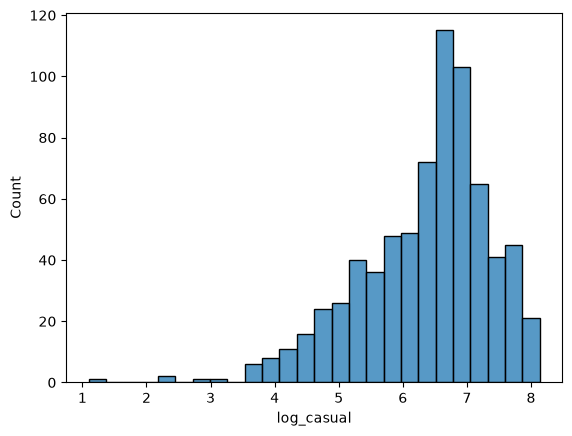

In [69]:
bike["log_casual"] = np.log1p(bike["casual"])

sns.histplot(data=bike, x="log_casual")

So this graph represents a left-skewed distribution this time. I believe that taking the log narrowed down the changes in the values. Keplers law did the same thing we did in the last lab/class. So this is the same idea in making the log transformation fix the behaviour of the graph to get a better fit of the data.